In [1]:
import numpy as np
import xarray as xr
from cloudpathlib import AnyPath
import matplotlib.pyplot as plt
import datetime

base_path = AnyPath("/Users/mawa7160/dev/data")

def julian_day_to_datetime(julian_dates):
    # The Julian day for the start of the Julian calendar is 1721423.5
    julian_start = 1721423.5
    
    # If the input is a single Julian date, convert it to a one-element array
    if isinstance(julian_dates, (int, float)):
        julian_dates = np.array([julian_dates])
    
    # Calculate the number of days from the start of the Julian calendar to the given Julian dates
    days_since_julian_start = julian_dates - julian_start
    
    # Convert the days to seconds
    seconds_since_julian_start = days_since_julian_start * 86400  # 60 seconds * 60 minutes * 24 hours
    
    # Create timedelta objects with the calculated seconds
    deltas = [datetime.timedelta(seconds=seconds) for seconds in seconds_since_julian_start]
    
    # Create datetime objects representing the dates and times
    datetime_objs = [datetime.datetime(1, 1, 1) + delta for delta in deltas]
    
    # If only one Julian date was provided, return a single datetime object
    if len(datetime_objs) == 1:
        return datetime_objs[0]
    
    return np.array(datetime_objs)

Load the TSIS TIM 6h data and make a nice object with it while removing the 0 values

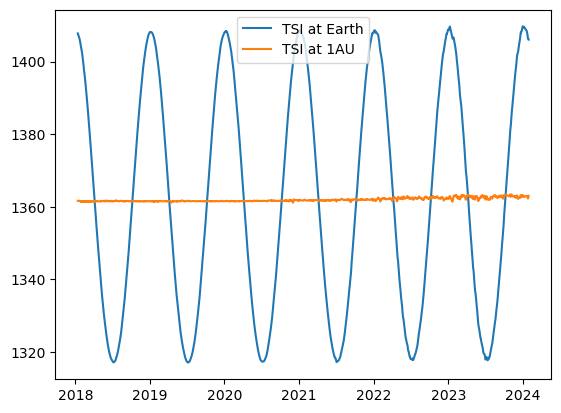

In [2]:
# Load the TSIS 6 hour data
tsis_6h_file_path = base_path / "TSIS" / "tsis_tsi_L3_c06h_02_2024.txt"
tsis_6h_raw_data = np.loadtxt(tsis_6h_file_path, skiprows=133)

# Convert the julian date to a datetime object
tsis_6h_days_julian = tsis_6h_raw_data[:,1]
tsis_6h_days_julian_avg = tsis_6h_raw_data[:,2]

tsis_6h_days_raw = julian_day_to_datetime(tsis_6h_days_julian)
tsis_6h_days_avg_raw = julian_day_to_datetime(tsis_6h_days_julian_avg)

# Select the data from the file
tsis_6h_tsi_1au_raw = tsis_6h_raw_data[:,4]
tsis_6h_tsi_1au_std_raw = tsis_6h_raw_data[:,8]
tsis_6h_tsi_at_earth_raw = tsis_6h_raw_data[:,9]
tsis_6h_tsi_at_earth_std_raw = tsis_6h_raw_data[:,13]
filter = tsis_6h_tsi_1au_raw > 0

# Remove the data that is 0 for the TSI 1AU data field as a proxy for missing data
tsis_6h_tsi_1au_std = tsis_6h_tsi_1au_std_raw[filter]
tsis_6h_tsi_at_earth = tsis_6h_tsi_at_earth_raw[filter]
tsis_6h_tsi_at_earth_std = tsis_6h_tsi_at_earth_std_raw[filter]
tsis_6h_days = tsis_6h_days_raw[filter]
tsis_6h_tsi_1au = tsis_6h_tsi_1au_raw[filter]

# Create an xarray dataset from the 6 hour data 
tsis_6h_data = xr.Dataset(
    {
        "tsi_1au": (["time"], tsis_6h_tsi_1au),
        "tsi_1au_std": (["time"], tsis_6h_tsi_1au_std),
        "tsi_at_earth": (["time"], tsis_6h_tsi_at_earth),
        "tsi_at_earth_std": (["time"], tsis_6h_tsi_at_earth_std),
    },
    coords={"time": tsis_6h_days},
)

# Fill in the missing data with linear interpolation so that the averaging built-in functions work correctly
tsis_6h_full = tsis_6h_data.resample(time="6H").interpolate("linear")

# Plots to show the data and give a quick check everything is working
plt.plot(tsis_6h_full.time, tsis_6h_full.tsi_at_earth, label="TSI at Earth")
plt.plot(tsis_6h_full.time, tsis_6h_full.tsi_1au, label="TSI at 1AU")
plt.legend()

In [3]:
# Calculate the annual average from the TSIS 6 hour data to the Gregorian calendar using built-in functions
tsis_19_22 = tsis_6h_full.sel(time=slice("2019-01-01T00:00:00", "2022-12-31T23:59:59"))
tsis_daily = tsis_19_22.resample(time="1D").mean()
tsis_gregorian_annual = tsis_daily.resample(time="1Y").mean()

# Calculate the annual average from the TSIS 6 hour data to the correct orbital year using manual calculations
# Year before a leap year. Starts ~12 hours late and ends 18 hours late
data_2019 = tsis_6h_full.sel(time=slice("2019-01-01T12:00:00", "2020-01-01T18:00:00"))
# Leap year starts 18 hours late and ends exactly on time with the additional day from February
data_2020 = tsis_6h_full.sel(time=slice("2020-01-01T18:00:00", "2021-01-01T00:00:00"))
# First year after a leap year. Starts on time and ends 6 hours late
data_2021 = tsis_6h_full.sel(time=slice("2021-01-01T00:00:00", "2022-01-01T06:00:00"))
# Second year after a leap year. Starts 6 hours late and ends 12 hours late
data_2022 = tsis_6h_full.sel(time=slice("2022-01-01T06:00:00", "2023-01-01T12:00:00"))

data2019_mean = data_2019.mean()
data2020_mean = data_2020.mean()
data2021_mean = data_2021.mean()
data2022_mean = data_2022.mean()
tsis_6h_accurate_annual = [data2019_mean, data2020_mean, data2021_mean, data2022_mean]
tsis_6h_accurate_annual_x = xr.concat(tsis_6h_accurate_annual, dim="time")

Text(0.5, 1.0, 'TSIS TIM Annual Average TOA TSI')

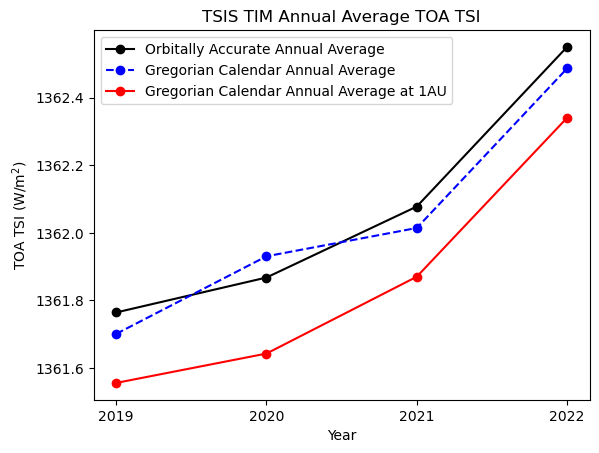

In [8]:
years = ["2019", "2020", "2021", "2022"]

plt.plot(years, tsis_6h_accurate_annual_x.tsi_at_earth, "-ko", label="Orbitally Accurate Annual Average")
plt.plot(years, tsis_gregorian_annual.tsi_at_earth, "--bo", label="Gregorian Calendar Annual Average")
plt.plot(years, tsis_gregorian_annual.tsi_1au, "-ro", label="Gregorian Calendar Annual Average at 1AU")
plt.legend()
plt.xlabel("Year")
plt.ylabel(f"TOA TSI (W/m$^2$)")
plt.title("TSIS TIM Annual Average TOA TSI")

Text(0, 0.5, 'PPM Difference from Gregorian Calendar to Orbital Year')

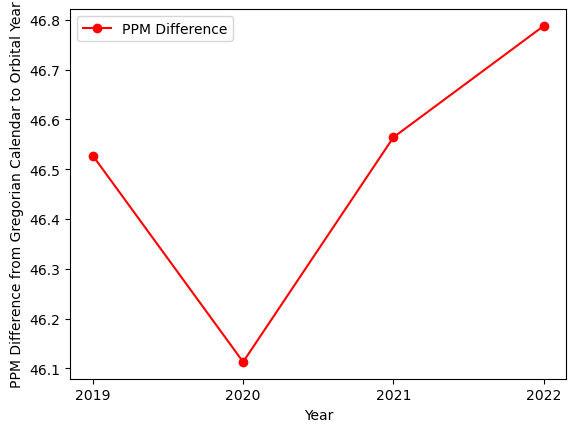

In [7]:
annual_abs_diff = np.abs(tsis_gregorian_annual.tsi_at_earth - tsis_6h_accurate_annual_x
                         .tsi_at_earth)
ppm_diff = annual_abs_diff / np.mean(tsis_6h_accurate_annual_x.tsi_at_earth) * 1e6
plt.plot(years, ppm_diff, "-ro", label="PPM Difference")
plt.legend()
plt.xlabel("Year")
plt.ylabel("PPM Difference from Gregorian Calendar to Orbital Year")